# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

Who:

I communicate with financial institutions, including banks and entities interested in taking a mortgage. Financial institutions can use insights from this dataset to draft and then implement common rules and principles, providing non-discriminatory, safe funding. Other entities interested in taking credit or a loan will find it helpful to focus on the most important features that lead to loan approval.

What:

I want to familiarize my audience with the most important features that lead to approval for financial funding, including loans, credit, and mortgages. I want them to understand the direction of correlation among these features and a general ranking of their importance. Then I would persuade them to implement systems that score such applications according to standardized principles and rules. 

How

I present the predictors (independent variables) and describe their statistics and the relationships among them (correlations) to assess whether they are useful for predicting the target variable. In addition, I implement visualizations to discover hidden patterns, the distribution of each variable, and possible outliers or broken (missing) data. Then I evaluate whether such data should be imputed or removed from the dataset. To prepare the dataset, the independent variables should also be properly cleaned and explained. In this case, the target variable is binary, indicating whether the mortgage loan was approved. 

In [104]:
%pwd

'c:\\Users\\pabis\\BU_University\\AI_for_Leaders'

In [105]:
# %cd ..

In [106]:
%pwd

'c:\\Users\\pabis\\BU_University\\AI_for_Leaders'

# 3. Homework - work with your own data

In [107]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

# Homework - work with your own data 

In this notebook I will work with two datasets:
- Modified Loan/Application Register (LAR)
- Default of Credit Card Clients

Link to the folder with datasets: https://drive.google.com/drive/u/1/folders/1fyPlz3VoDgJHR7h1Bjo-QeJjK8m4Dh4p

How to start working with this notebook:
1. Create a project directory and make sure that your Jupyter Notebook file is saved inside this directory;
2. Inside the project directory, create two folders for the datasets: LAR_data_raw and loan_dataset
3. Check your current working directory by running: %pwd
4. If you are not currently in the project directory, change the working directory by running: %cd your_directory path

## Modified Loan/Application Register (LAR)

Dataset source: https://ffiec.cfpb.gov/data-publication/modified-lar/2024; Year: 2024

I chose the BFSI project titled "Financial Risk Modeling: From Loan Approval to Default and Bankruptcy."

This is a project I worked on in the last semester. I chose this dataset because it was one of the datasets our group proposed in the Milestone. Originally, this dataset was not included in the selection set due to its enormous size. However, I wrote code to download and prepare this dataset in compliance with the requirements for the current project. The Learning facilitators approved this for further work.

In [108]:
# To start working with this dataset, I have to read it from the LAR_data_raw, create representative sample of this dataset, assess its correctness, and save it to the disc.

from pathlib import Path
import time


# 1. Setting folders for the project
# If you wnat to use this dataset just downlaod dataset for 2024 year from
# https://ffiec.cfpb.gov/data-publication/modified-lar/2025
# And save it in a file "data_raw". Then you can use this code to process it.

PROJECT_DIR = Path.cwd() # We must be in the project directory

RAW_DATA_PATH = PROJECT_DIR / "LAR_data_raw" / "2024_combined_mlar_header.txt" # folder for the raw file

OUTPUT_DIR = PROJECT_DIR / "data_processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PARQUET_PATH = OUTPUT_DIR / "hmda_random_sample_20pct.parquet"
OUTPUT_CSV_PATH = OUTPUT_DIR / "hmda_random_sample_20pct.csv"

print("Project directory:", PROJECT_DIR)
print("Raw data path:", RAW_DATA_PATH)
print("Output directory:", OUTPUT_DIR)

CHUNKSIZE = 100_000  #this file is too big so we must chunk it
SAMPLE_FRAC = 0.20   # We should retain randomness so we will select 20% from the partciular chunk on a tandom way
RANDOM_SEED = 42 # We will set random_seed to make the project reproducttible


# 2. Random chunk-based sampling

start_time = time.time()

sample_parts = []

for i, chunk in enumerate(pd.read_csv(
    RAW_DATA_PATH,
    sep="|",
    dtype=str,
    chunksize=CHUNKSIZE
)):
    sampled_chunk = chunk.sample(
        frac=SAMPLE_FRAC,
        random_state=RANDOM_SEED + i
    )

    sample_parts.append(sampled_chunk)

    print(f"Finished chunk {i + 1}: sampled {len(sampled_chunk):,} rows")


# 3. Combine sampled chunks

df_random = pd.concat(sample_parts, ignore_index=True)

print("Final sample shape:", df_random.shape)


# 4. Save the sampled dataset

df_random.to_parquet(
    OUTPUT_PARQUET_PATH,  # Parquet format is much more fiendlyu for large datastes, smaller (binary), faster, and retain data format.
    index=False
)

df_random.to_csv(
    OUTPUT_CSV_PATH,
    index=False
)

end_time = time.time()

print(f"Saved Parquet file to: {OUTPUT_PARQUET_PATH}")
print(f"Saved CSV file to: {OUTPUT_CSV_PATH}")
print(f"Total time: {(end_time - start_time) / 60:.2f} minutes")

df_random.head()

Project directory: c:\Users\pabis\BU_University\AI_for_Leaders
Raw data path: c:\Users\pabis\BU_University\AI_for_Leaders\LAR_data_raw\2024_combined_mlar_header.txt
Output directory: c:\Users\pabis\BU_University\AI_for_Leaders\data_processed
Finished chunk 1: sampled 20,000 rows
Finished chunk 2: sampled 20,000 rows
Finished chunk 3: sampled 20,000 rows
Finished chunk 4: sampled 20,000 rows
Finished chunk 5: sampled 20,000 rows
Finished chunk 6: sampled 20,000 rows
Finished chunk 7: sampled 20,000 rows
Finished chunk 8: sampled 20,000 rows
Finished chunk 9: sampled 20,000 rows
Finished chunk 10: sampled 20,000 rows
Finished chunk 11: sampled 20,000 rows
Finished chunk 12: sampled 20,000 rows
Finished chunk 13: sampled 20,000 rows
Finished chunk 14: sampled 20,000 rows
Finished chunk 15: sampled 20,000 rows
Finished chunk 16: sampled 20,000 rows
Finished chunk 17: sampled 20,000 rows
Finished chunk 18: sampled 20,000 rows
Finished chunk 19: sampled 20,000 rows
Finished chunk 20: sampled

,activity_year,lei,loan_type,loan_purpose,preapproval,construction_method,occupancy_type,loan_amount,action_taken,state_code,...,submission_of_application,initially_payable_to_institution,aus_1,aus_2,aus_3,aus_4,aus_5,reverse_mortgage,open_end_line_of_credit,business_or_commercial_purpose
0,2024,5493001SXWZ4OFP8Z903,1,1,2,1,1,285000,1,NV,...,1,1,1,NaN,NaN,NaN,NaN,2,2,2
1,2024,5493001SXWZ4OFP8Z903,1,1,2,1,1,505000,4,OR,...,1,1,1,NaN,NaN,NaN,NaN,2,2,2
2,2024,5493001HHBUTXHS7TZ96,1,1,2,1,1,655000,1,CA,...,1,1,1,NaN,NaN,NaN,NaN,2,2,2
3,2024,5493001SXWZ4OFP8Z903,2,1,2,1,1,315000,3,FL,...,1,1,3,NaN,NaN,NaN,NaN,2,2,2
4,2024,5493001SXWZ4OFP8Z903,1,1,2,1,1,365000,1,CA,...,1,1,1,NaN,NaN,NaN,NaN,2,2,2


In [109]:
df_random = pd.read_parquet(OUTPUT_PARQUET_PATH)
df = df_random.copy()
df.head()

,activity_year,lei,loan_type,loan_purpose,preapproval,construction_method,occupancy_type,loan_amount,action_taken,state_code,...,submission_of_application,initially_payable_to_institution,aus_1,aus_2,aus_3,aus_4,aus_5,reverse_mortgage,open_end_line_of_credit,business_or_commercial_purpose
0,2024,5493001SXWZ4OFP8Z903,1,1,2,1,1,285000,1,NV,...,1,1,1,None,None,None,None,2,2,2
1,2024,5493001SXWZ4OFP8Z903,1,1,2,1,1,505000,4,OR,...,1,1,1,None,None,None,None,2,2,2
2,2024,5493001HHBUTXHS7TZ96,1,1,2,1,1,655000,1,CA,...,1,1,1,None,None,None,None,2,2,2
3,2024,5493001SXWZ4OFP8Z903,2,1,2,1,1,315000,3,FL,...,1,1,3,None,None,None,None,2,2,2
4,2024,5493001SXWZ4OFP8Z903,1,1,2,1,1,365000,1,CA,...,1,1,1,None,None,None,None,2,2,2


In [110]:
df.shape

(2451832, 85)

In [111]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2451832 entries, 0 to 2451831
Data columns (total 85 columns):
 #   Column                                    Non-Null Count    Dtype 
---  ------                                    --------------    ----- 
 0   activity_year                             2451832 non-null  object
 1   lei                                       2451832 non-null  object
 2   loan_type                                 2451832 non-null  object
 3   loan_purpose                              2451832 non-null  object
 4   preapproval                               2451832 non-null  object
 5   construction_method                       2451832 non-null  object
 6   occupancy_type                            2451832 non-null  object
 7   loan_amount                               2451832 non-null  object
 8   action_taken                              2451832 non-null  object
 9   state_code                                2408749 non-null  object
 10  county_code       

In [112]:
# We have only one value (low variance) so we drop this column fo the real analysis. 
df["activity_year"].value_counts(normalize = True) #the proportion of the target column is appropriate

activity_year
2024    1.0
Name: proportion, dtype: float64

In [113]:
df["action_taken"].value_counts(normalize = True) #the proportion of the target column is appropriate

action_taken
1    0.505235
3    0.171426
4    0.125836
6    0.104085
5    0.047591
2    0.029514
8    0.012513
7    0.003801
Name: proportion, dtype: float64

Chronological steps for the dataset preparation:
1. choose columns
2. clean missing-value strings
3. convert true numeric quantities
4. keep coded variables as categories
5. inspect missing values and category values (this step was added during the project development)
6. create a useful feature: has_co_applicant (this step was added during the project development)
7. clean special age codes (this step was added during the project development)

In [114]:
selected_columns = [
    # 1. Decision / outcome columns
  
    "action_taken",

    # 2. Time and institution

    "activity_year",
    "lei",

    # 3. Loan/application characteristics

    "loan_type",
    "loan_purpose",
    "preapproval",
    "construction_method",
    "occupancy_type",
    "loan_amount",
    "lien_status",

    # 4. Location

    "state_code",
    "county_code",
    "census_tract",

    # 5. Borrower financial variables

    "income",
    "debt_to_income_ratio",
    "combined_loan_to_value_ratio",
    "loan_term",
    "property_value",
    "total_units",

    # 6. Applicant demographics

    "applicant_ethnicity_1",
    "applicant_race_1",
    "applicant_sex",
    "applicant_age",
    "applicant_age_above_62",

    # 7. Co-applicant demographics

    "co_applicant_ethnicity_1",
    "co_applicant_race_1",
    "co_applicant_sex",
    "co_applicant_age",
    "co_applicant_age_above_62",

    # 8. Credit/underwriting process

    "applicant_credit_scoring_model",
    "co_applicant_credit_scoring_model",
    "aus_1",
    "submission_of_application",
    "initially_payable_to_institution",

    # 9. Risky loan product features

    "balloon_payment",
    "interest_only_payment",
    "negative_amortization",
    "other_non_amortizing_features",
    "reverse_mortgage",
    "open_end_line_of_credit",
    "business_or_commercial_purpose",

     # Denial reasons: useful later, but only for denied applications
    "denial_reason_1",

    # new columns
    
    # Pricing / mortgage cost variables, they are better for a separate originated-loans pricing EDA
    # They are great for EDA but but dangerous for prediction (Often known after approval/origination)
    "interest_rate",
    "total_loan_costs",
    "origination_charges",

    # High-cost / special loan status (but Related to final loan pricing/high-cost status!)
    "hoepa_status",
    
    # Manufactured housing / property-specific variables
    # Do manufactured-home-secured applications have different approval/denial rates?
    "manufactured_home_secured_property_type",
    "manufactured_home_land_property_interest",

    # Post-origination / market outcome (but Post-origination information: do not add to the model. Good for EDA)
    "purchaser_type",

    # observed columns
    # How often are demographic fields based on observation rather than direct applicant reporting?
    # Useful, but fairness-sensitive. Maybe they should be excluded from the  modelling
    # The lender inferred/recorded the information

    "applicant_ethnicity_observed",
    "applicant_race_observed",
    "applicant_sex_observed",
    "co_applicant_ethnicity_observed",
    "co_applicant_race_observed",
    "co_applicant_sex_observed"

    
]

In [115]:
# Checking for the col existence

missing_from_raw = [
    col for col in selected_columns
    if col not in df_random.columns
]

missing_from_raw

[]

In [116]:
df_selected = df_random[selected_columns].copy()

print("Original shape:", df_random.shape)
print("Selected shape:", df_selected.shape)

df_selected.info(show_counts=True)

Original shape: (2451832, 85)
Selected shape: (2451832, 55)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2451832 entries, 0 to 2451831
Data columns (total 55 columns):
 #   Column                                    Non-Null Count    Dtype 
---  ------                                    --------------    ----- 
 0   action_taken                              2451832 non-null  object
 1   activity_year                             2451832 non-null  object
 2   lei                                       2451832 non-null  object
 3   loan_type                                 2451832 non-null  object
 4   loan_purpose                              2451832 non-null  object
 5   preapproval                               2451832 non-null  object
 6   construction_method                       2451832 non-null  object
 7   occupancy_type                            2451832 non-null  object
 8   loan_amount                               2451832 non-null  object
 9   lien_status                   

In [117]:
# The second step of data cleaning, after choosing proper columns,
# is to clean missing-value strings.
# According to the dataset documentation, some fields contain values
# such as "NA" and "Exempt". We translate them into real pandas NA values.
# We should also remember that some age columns contain special values
# such as "8888" and "9999".

df_typed = df_selected.copy()

# Replace common HMDA missing-value text with real pandas missing values.
df_typed = df_typed.replace(
    ["", "NA", "Exempt", "exempt"],
    pd.NA
)

In [118]:
# The third step is to convert true numeric quantities

numeric_columns = [
    "loan_amount",
    "income",
    "combined_loan_to_value_ratio",
    "loan_term",
    "property_value",

    # New pricing / cost columns
    "interest_rate",
    "total_loan_costs",
    "origination_charges",

]

for col in numeric_columns:
    df_typed[col] = pd.to_numeric(df_typed[col], errors="coerce")

    # coerce mean that if pandas cannot convert something to a number, it replaces it with missing value.

In [119]:
# Let's create income to dollars (original dataset reports income in thousands)

df_typed["income_dollars"] = df_typed["income"] * 1000

In [120]:
# fourt step: Convert coded variables to category datatype


categorical_columns = [
    # Target  variable
    "action_taken",

    # Loan/application codes # We will handle it later as OneHotEncoder or CatBoost-style categorical handling
    "loan_type",
    "loan_purpose",
    "preapproval",
    "construction_method",
    "occupancy_type",
    "lien_status",
    "activity_year",

    # String binned variables. These have an order so we will create  ordered/numeric transformation later/ For now we chnage strring sto category.
    "debt_to_income_ratio",
    "applicant_age",
    "co_applicant_age",
    "total_units",

    # Demographic codes
    "applicant_ethnicity_1",
    "applicant_race_1",
    "applicant_sex",
    "applicant_age_above_62",

    "co_applicant_ethnicity_1",
    "co_applicant_race_1",
    "co_applicant_sex",
    "co_applicant_age_above_62", # this column will have many missing valuyes, because  

    # Underwriting / process codes
    "applicant_credit_scoring_model",
    "co_applicant_credit_scoring_model",
    "aus_1",
    "submission_of_application",
    "initially_payable_to_institution",

    # Risky loan product codes
    "balloon_payment",
    "interest_only_payment",
    "negative_amortization",
    "other_non_amortizing_features",
    "reverse_mortgage",
    "open_end_line_of_credit",
    "business_or_commercial_purpose",

    # Denial reason code
    "denial_reason_1",

    # New categorical EDA columns
    "hoepa_status",
    "manufactured_home_secured_property_type",
    "manufactured_home_land_property_interest",
    "purchaser_type",

    # Observed demographic collection-method columns
    "applicant_ethnicity_observed",
    "applicant_race_observed",
    "applicant_sex_observed",
    "co_applicant_ethnicity_observed",
    "co_applicant_race_observed",
    "co_applicant_sex_observed",


]

for col in categorical_columns:
    df_typed[col] = df_typed[col].astype("category")


In [121]:
# Fifth step: Convert identifier/location columns to string

string_columns = [
    "lei",
    "state_code",
    "county_code",
    "census_tract",
]

for col in string_columns:
    df_typed[col] = df_typed[col].astype("string")

In [122]:
# Inspection

df_typed.info(show_counts=True)

print("\nData type summary:")
print(df_typed.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2451832 entries, 0 to 2451831
Data columns (total 56 columns):
 #   Column                                    Non-Null Count    Dtype   
---  ------                                    --------------    -----   
 0   action_taken                              2451832 non-null  category
 1   activity_year                             2451832 non-null  category
 2   lei                                       2451832 non-null  string  
 3   loan_type                                 2451832 non-null  category
 4   loan_purpose                              2451832 non-null  category
 5   preapproval                               2451832 non-null  category
 6   construction_method                       2451832 non-null  category
 7   occupancy_type                            2451832 non-null  category
 8   loan_amount                               2451832 non-null  int64   
 9   lien_status                               2451832 non-null  category

In [123]:
df_typed.dtypes.astype(str).value_counts()

category    43
float64      8
string       4
int64        1
Name: count, dtype: int64

In [124]:
# Missing value summary
missing_table = pd.DataFrame({
    "missing_count": df_typed.isna().sum(),
    "missing_percent": df_typed.isna().mean().mul(100).round(2),
    "dtype": df_typed.dtypes.astype(str)
}).sort_values("missing_percent", ascending=False)

missing_table

,missing_count,missing_percent,dtype
co_applicant_age_above_62,1568376,63.97,category
total_loan_costs,1348411,55.00,float64
origination_charges,1337069,54.53,float64
interest_rate,904431,36.89,float64
debt_to_income_ratio,870214,35.49,category
combined_loan_to_value_ratio,863919,35.24,float64
property_value,549781,22.42,float64
income,356333,14.53,float64
income_dollars,356333,14.53,float64
applicant_age_above_62,292565,11.93,category


In [125]:
# Check if the category contains a starnge data

for col in df_typed.select_dtypes(include="category").columns:
    print(f"\n{col}")
    print(df_typed[col].value_counts(dropna=False).head(20))


action_taken
action_taken
1    1238751
3     420307
4     308529
6     255198
5     116685
2      72363
8      30680
7       9319
Name: count, dtype: int64

activity_year
activity_year
2024    2451832
Name: count, dtype: int64

loan_type
loan_type
1    1859388
2     373917
3     203314
4      15213
Name: count, dtype: int64

loan_purpose
loan_purpose
1     1316315
32     347351
4      279587
31     264186
2      240454
5        3939
Name: count, dtype: int64

preapproval
preapproval
2    2372051
1      79781
Name: count, dtype: int64

construction_method
construction_method
1    2314256
2     137576
Name: count, dtype: int64

occupancy_type
occupancy_type
1    2219390
3     186063
2      46379
Name: count, dtype: int64

lien_status
lien_status
1    1881520
2     570312
Name: count, dtype: int64

debt_to_income_ratio
debt_to_income_ratio
NaN         870214
30%-<36%    219392
20%-<30%    215135
50%-60%     164633
>60%        123972
<20%         92612
49           79904
44           6627

co_applicant_age_above_62 is not a real problem. The above code showed that the column contains missing mostly because many applications have no co-applicant. The value counts confirm that co_applicant_age contains many 9999 values, which means no co-applicant.

In [126]:
# We create this feature before replacing 9999 with pd.NA.!
#  We can create an additional column (useful feature) such as:

df_typed["has_co_applicant"] = (
    df_typed["co_applicant_age"].astype("string") != "9999"
).astype("Int8") 

# I chose Int instead of int because Int8 is pandas’ nullable integer type. 
# It can handle missing values if they appear later

In [127]:
# In addition we can replace special age codes with real missing values

df_typed["applicant_age"] = df_typed["applicant_age"].replace("8888", pd.NA) # 888 means age not available!
df_typed["co_applicant_age"] = df_typed["co_applicant_age"].replace(["8888", "9999"], pd.NA)

# df_typed["applicant_age"] = df_typed["applicant_age"].astype("category")
# df_typed["co_applicant_age"] = df_typed["co_applicant_age"].astype("category")



C:\Users\pabis\AppData\Local\Temp\ipykernel_10864\3503608287.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_typed["applicant_age"] = df_typed["applicant_age"].replace("8888", pd.NA) # 888 means age not available!
C:\Users\pabis\AppData\Local\Temp\ipykernel_10864\3503608287.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_typed["co_applicant_age"] = df_typed["co_applicant_age"].replace(["8888", "9999"], pd.NA)


In [128]:
# We can check again missing values:

missing_table_after_age_cleaning = pd.DataFrame({
    "missing_count": df_typed.isna().sum(),
    "missing_percent": df_typed.isna().mean().mul(100).round(2),
    "dtype": df_typed.dtypes.astype(str)
}).sort_values("missing_percent", ascending=False)

missing_table_after_age_cleaning

,missing_count,missing_percent,dtype
co_applicant_age_above_62,1568376,63.97,category
co_applicant_age,1568376,63.97,category
total_loan_costs,1348411,55.00,float64
origination_charges,1337069,54.53,float64
interest_rate,904431,36.89,float64
debt_to_income_ratio,870214,35.49,category
combined_loan_to_value_ratio,863919,35.24,float64
property_value,549781,22.42,float64
income,356333,14.53,float64
income_dollars,356333,14.53,float64


In [129]:
df_typed["has_co_applicant"].value_counts(normalize = True, dropna=False)

has_co_applicant
0    0.54356
1    0.45644
Name: proportion, dtype: Float64

In [130]:
# My next step will be to analyze missing values and category distributions before creating numeric helper columns or choosing the target.
# For target I will choose ony two categories: Approved and denied.

In [131]:
# save this dataset for further analysis

OUTPUT_DIR = Path.cwd() / "data_processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PARQUET_PATH = OUTPUT_DIR / "hmda_selected_typed_cleaned_20pct.parquet"
OUTPUT_CSV_PATH = OUTPUT_DIR / "hmda_selected_typed_cleaned_20pct.csv"

df_typed.to_parquet(OUTPUT_PARQUET_PATH, index=False)

# I wqill save CSV only because I want an "easy-to-open" inspection file.
# Parquet is better for the further work because it keeps dtypes better and is smaller/faster.
df_typed.to_csv(OUTPUT_CSV_PATH, index=False)

print("Saved Parquet file to:", OUTPUT_PARQUET_PATH)
print("Saved CSV file to:", OUTPUT_CSV_PATH)
print("Final shape:", df_typed.shape)

Saved Parquet file to: c:\Users\pabis\BU_University\AI_for_Leaders\data_processed\hmda_selected_typed_cleaned_20pct.parquet
Saved CSV file to: c:\Users\pabis\BU_University\AI_for_Leaders\data_processed\hmda_selected_typed_cleaned_20pct.csv
Final shape: (2451832, 57)


The most critical decision is to choose the modelling approach and target.
My main goal is to predict if the loan will be approved or denied.
I should choose the following categories from the action_taken:
- 1 = originated
- 2 = approved but not accepted
- 3 = denied

In [132]:
# Let's check if the file was correctly saved and continue the analysis
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path.cwd() # You should be in a project folder # Maybe i can do it with Path(__file__).resolve().parent)
DATA_PATH = PROJECT_DIR / "data_processed" / "hmda_selected_typed_cleaned_20pct.parquet"

df_typed = pd.read_parquet(DATA_PATH)

print(df_typed.shape)
df_typed.head()

(2451832, 57)


,action_taken,activity_year,lei,loan_type,loan_purpose,preapproval,construction_method,occupancy_type,loan_amount,lien_status,...,manufactured_home_land_property_interest,purchaser_type,applicant_ethnicity_observed,applicant_race_observed,applicant_sex_observed,co_applicant_ethnicity_observed,co_applicant_race_observed,co_applicant_sex_observed,income_dollars,has_co_applicant
0,1,2024,5493001SXWZ4OFP8Z903,1,1,2,1,1,285000,1,...,5,1,2,2,2,4,4,4,65000.0,0
1,4,2024,5493001SXWZ4OFP8Z903,1,1,2,1,1,505000,1,...,5,0,2,2,2,2,2,2,106000.0,1
2,1,2024,5493001HHBUTXHS7TZ96,1,1,2,1,1,655000,1,...,5,6,2,2,2,4,4,4,143000.0,0
3,3,2024,5493001SXWZ4OFP8Z903,2,1,2,1,1,315000,1,...,5,0,2,2,2,2,2,2,62000.0,1
4,1,2024,5493001SXWZ4OFP8Z903,1,1,2,1,1,365000,1,...,5,1,2,2,2,2,2,2,116000.0,1


In [133]:
# describe function enable us to assess statistics such asL median and mean. 
# If we choose also paramater = all we will also observe statistics for the categorical variables, including mode

df_typed.describe()

,loan_amount,income,combined_loan_to_value_ratio,loan_term,property_value,interest_rate,total_loan_costs,origination_charges,income_dollars,has_co_applicant
count,2.451832e+06,2.095499e+06,1.587913e+06,2.354161e+06,1.902051e+06,1.547401e+06,1.103421e+06,1.114763e+06,2.095499e+06,2451832.0
mean,3.145136e+05,3.863088e+02,1.109487e+03,3.241893e+02,5.431753e+05,7.045893e+00,7.710465e+03,3.495552e+03,3.863088e+05,0.45644
std,2.651491e+06,2.956565e+05,6.869301e+05,8.005874e+01,4.150189e+06,1.709271e+00,2.261407e+04,4.398591e+03,2.956565e+08,0.498099
min,5.000000e+03,-2.400000e+04,1.000000e-03,1.000000e+00,5.000000e+03,0.000000e+00,0.000000e+00,0.000000e+00,-2.400000e+07,0.0
25%,1.050000e+05,6.700000e+01,6.015000e+01,3.600000e+02,2.550000e+05,6.250000e+00,3.649620e+03,9.599500e+02,6.700000e+04,0.0
50%,2.250000e+05,1.040000e+02,7.914000e+01,3.600000e+02,3.850000e+05,6.750000e+00,6.264090e+03,1.997310e+03,1.040000e+05,0.0
75%,3.750000e+05,1.650000e+02,9.293800e+01,3.600000e+02,5.850000e+05,7.624000e+00,1.035172e+04,4.902890e+03,1.650000e+05,1.0
max,1.687505e+09,4.274317e+08,6.000000e+08,3.292000e+03,2.147484e+09,2.300000e+01,2.224208e+07,1.406250e+06,4.274317e+11,1.0


In [134]:
# I chose also paramater = all to show the statistics also for the categorical variables, including mode. 
df_typed.describe(include = "all")

,action_taken,activity_year,lei,loan_type,loan_purpose,preapproval,construction_method,occupancy_type,loan_amount,lien_status,...,manufactured_home_land_property_interest,purchaser_type,applicant_ethnicity_observed,applicant_race_observed,applicant_sex_observed,co_applicant_ethnicity_observed,co_applicant_race_observed,co_applicant_sex_observed,income_dollars,has_co_applicant
count,2451832,2451832,2451832,2451832,2451832,2451832,2451832,2451832,2.451832e+06,2451832,...,2451832,2451832,2451832,2451832,2451832,2451832,2451832,2451832,2.095499e+06,2451832.0
unique,8,1,4903,4,6,2,2,3,NaN,2,...,6,11,3,3,3,4,4,4,NaN,<NA>
top,1,2024,549300FGXN1K3HLB1R50,1,1,2,1,1,NaN,1,...,5,0,2,2,2,4,4,4,NaN,<NA>
freq,1238751,2451832,110813,1859388,1316315,2372051,2314256,2219390,NaN,1881520,...,2261289,1490264,2047379,2046860,2046075,1332898,1331757,1333067,NaN,<NA>
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.145136e+05,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.863088e+05,0.45644
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.651491e+06,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.956565e+08,0.498099
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e+03,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.400000e+07,0.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.050000e+05,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.700000e+04,0.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.250000e+05,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.040000e+05,0.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.750000e+05,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.650000e+05,1.0


#### Interpretation of the data distribution:

50% of loans are below 225,000, and 50% are above 225,000. 99% of loans are below 1,445,000. In addition only 0.5% of loans are above 1,995,000.

The above table provide for us a valuable insight that the loan_amount is strongly right-skewed. Most loans are in a normal residential mortgage range, but a small number of very large loans stretch the distribution.

#### What values seems impossible/ invalid:

Income min: -24000 --> impossible value

income max: 427,431,663 - probably invalid

combined_loan_to_value_ratio max : 600,000,000

loan_term max: 3292 months --> ecomically unrealistic

loan_amount max: 1,687,505,000 --> extreme, should be investigated

property_value max: 2,147,484,000 --> suspicious, possibly error/sentinel/rare case

Let's assess below distribution of the above feilds using quantiles

In [135]:
# Describe() function showed that there are outliers in the dataset. Let's find the structure of the dataset using percentils in the loan_amount column. 

df_typed["property_value"].quantile([
    0.00,
    0.01,
    0.05,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    0.995,
    0.9999999999,
    1.00
])

0.000    5.000000e+03
0.010    6.500000e+04
0.050    1.250000e+05
0.250    2.550000e+05
0.500    3.850000e+05
0.750    5.850000e+05
0.900    8.850000e+05
0.950    1.215000e+06
0.990    2.505000e+06
0.995    3.415000e+06
1.000    2.147484e+09
1.000    2.147484e+09
Name: property_value, dtype: float64

In [136]:
# Describe() function showed that there are outliers in the dataset. Let's find the structure of the dataset using percentils in the loan_amount column. 

df_typed["loan_term"].quantile([
    0.00,
    0.01,
    0.05,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    0.995,
    0.9999999999,
    1.00
])

0.000       1.000000
0.010      18.000000
0.050     120.000000
0.250     360.000000
0.500     360.000000
0.750     360.000000
0.900     360.000000
0.950     360.000000
0.990     480.000000
0.995     480.000000
1.000    3291.931258
1.000    3292.000000
Name: loan_term, dtype: float64

In [137]:
df_typed["combined_loan_to_value_ratio"].quantile([
    0.00,
    0.01,
    0.05,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    0.995,
    0.9999999999,
    1.00
])

0.000    1.000000e-03
0.010    9.470000e+00
0.050    2.579000e+01
0.250    6.015000e+01
0.500    7.914000e+01
0.750    9.293800e+01
0.900    9.747800e+01
0.950    1.000000e+02
0.990    1.049720e+02
0.995    1.142650e+02
1.000    6.000000e+08
1.000    6.000000e+08
Name: combined_loan_to_value_ratio, dtype: float64

In [138]:
# Describe() function showed that there are outliers in the dataset. Let's find the structure of the dataset using percentils in the loan_amount column. 

df_typed["income_dollars"].quantile([
    0.00,
    0.01,
    0.05,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    0.995,
    0.9999999999,
    1.00
])

0.000   -2.400000e+07
0.010    0.000000e+00
0.050    3.200000e+04
0.250    6.700000e+04
0.500    1.040000e+05
0.750    1.650000e+05
0.900    2.630000e+05
0.950    3.680000e+05
0.990    8.380000e+05
0.995    1.234000e+06
1.000    4.273446e+11
1.000    4.274317e+11
Name: income_dollars, dtype: float64

<Axes: >

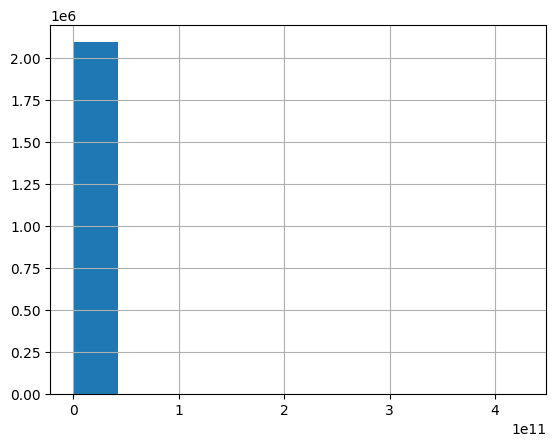

In [139]:
df_typed["income_dollars"].hist()

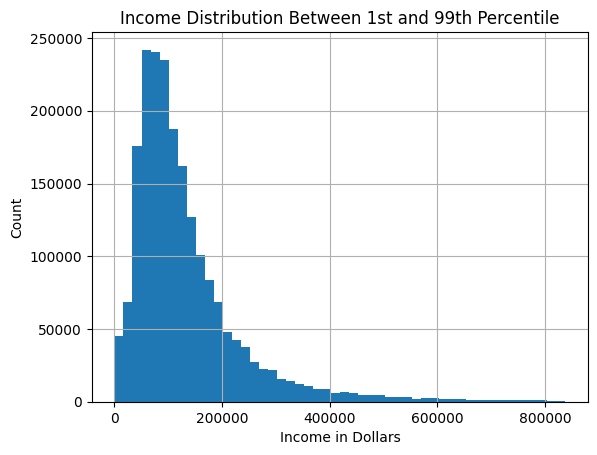

Lower limit: 0.0
Upper limit: 838000.0


In [140]:
# The below hisogram shows values of income_dollars without outliers. It will be reasonble to remove them for the future analysis. 

import matplotlib.pyplot as plt


lower_limit = df_typed["income_dollars"].quantile(0.01)
upper_limit = df_typed["income_dollars"].quantile(0.99)

income_filtered = df_typed.loc[
    df_typed["income_dollars"].between(lower_limit, upper_limit),
    "income_dollars"
]

income_filtered.hist(bins=50)

plt.title("Income Distribution Between 1st and 99th Percentile")
plt.xlabel("Income in Dollars")
plt.ylabel("Count")
plt.show()

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

In [141]:
# Let's claculate the number and proportion ofthe invalid and economically impossible values
invalid_rules = {
    "income_negative": df_typed["income"] < 0,
    "income_extremely_high": df_typed["income"] > 10_000,

    "income_dol_negative": df_typed["income_dollars"] < 0,
    "income_dol_extremely_high": df_typed["income_dollars"] > 10_000_000,

    "cltv_nonpositive": df_typed["combined_loan_to_value_ratio"] <= 0,
    "cltv_too_high": df_typed["combined_loan_to_value_ratio"] > 200,

    "loan_term_too_short": df_typed["loan_term"] < 6,
    "loan_term_too_long": df_typed["loan_term"] > 480,

    "loan_amount_nonpositive": df_typed["loan_amount"] <= 0,
    "loan_amount_extremely_high": df_typed["loan_amount"] > 10_000_000,

    "property_value_nonpositive": df_typed["property_value"] <= 0,
    "property_value_extremely_high": df_typed["property_value"] > 10_000_000,
}

for rule_name, mask in invalid_rules.items():
    print(rule_name)
    print("Number:", mask.sum())
    print("Percentage:", round(mask.mean() * 100, 4))
    print()

income_negative
Number: 1524
Percentage: 0.0622

income_extremely_high
Number: 317
Percentage: 0.0129

income_dol_negative
Number: 1524
Percentage: 0.0622

income_dol_extremely_high
Number: 317
Percentage: 0.0129

cltv_nonpositive
Number: 0
Percentage: 0.0

cltv_too_high
Number: 1057
Percentage: 0.0431

loan_term_too_short
Number: 1435
Percentage: 0.0585

loan_term_too_long
Number: 570
Percentage: 0.0232

loan_amount_nonpositive
Number: 0
Percentage: 0.0

loan_amount_extremely_high
Number: 1349
Percentage: 0.055

property_value_nonpositive
Number: 0
Percentage: 0.0

property_value_extremely_high
Number: 1722
Percentage: 0.0702



In [142]:
combined_invalid_mask = (
    (df_typed["income"] < 0) |
    (df_typed["income"] > 10_000) |
    (df_typed["income_dollars"] < 0) |
    (df_typed["income_dollars"] > 10_000_000) |
    (df_typed["combined_loan_to_value_ratio"] <= 0) |
    (df_typed["combined_loan_to_value_ratio"] > 200) |
    (df_typed["loan_term"] < 6) |
    (df_typed["loan_term"] > 480) |
    (df_typed["loan_amount"] <= 0) |
    (df_typed["loan_amount"] > 10_000_000) |
    (df_typed["property_value"] <= 0) |
    (df_typed["property_value"] > 10_000_000)
)

print("Rows with at least one invalid/suspicious value:", combined_invalid_mask.sum())
print("Percentage:", round(combined_invalid_mask.mean() * 100, 4))

Rows with at least one invalid/suspicious value: 7044
Percentage: 0.2873


The above analysis showed that the values it is important to investigate and handle extreme values. Some values appear economically impossible or highly implausible, such as negative income, extremely large combined loan-to-value ratios, and unrealistic loan terms. These should be removed or converted to missing values. However, not all high values should be removed automatically, because some large loan amounts or property values may represent real but rare observations.

The combined invalid-value mask identified 7,044 rows with at least one invalid or suspicious value, representing only 0.2873% of the dataset. This suggests that the dataset is generally clean with respect to the selected numeric variables, although these problematic rows should still be investigated or removed before modeling.

In [143]:
# Before further analysis I will remove rows with at least one invalid or highly suspicious numeric value based on predefined domain rules

df_clean = df_typed.loc[~combined_invalid_mask].copy()

print("Original shape:", df_typed.shape)
print("Clean shape:", df_clean.shape)
print("Rows removed:", df_typed.shape[0] - df_clean.shape[0])
print("Percentage removed:", round((1 - len(df_clean) / len(df_typed)) * 100, 4))

Original shape: (2451832, 57)
Clean shape: (2444788, 57)
Rows removed: 7044
Percentage removed: 0.2873


In [144]:
# We should check duplicates percentage

duplicate_count = df_clean.duplicated(keep="first").sum()
duplicate_percent = duplicate_count / len(df_clean) * 100

print("Duplicate rows after first:", duplicate_count)
print(f"Duplicate percent: {duplicate_percent:.4f}%")

Duplicate rows after first: 1538
Duplicate percent: 0.0629%


In [145]:
# Then check all the rowqs involved in duplicate group

all_duplicate_rows = df_clean[df_clean.duplicated(keep= False)]

print("Rows involved in duplicate groups:", len(all_duplicate_rows))

Rows involved in duplicate groups: 2832


In [146]:
# The most repeated profile

duplicate_profiles = (
    df_clean
    .value_counts(dropna=False)
    .reset_index(name="count")
    .query("count > 1")
    .sort_values("count", ascending=False)
)

duplicate_profiles.head(10)

,action_taken,activity_year,lei,loan_type,loan_purpose,preapproval,construction_method,occupancy_type,loan_amount,lien_status,...,purchaser_type,applicant_ethnicity_observed,applicant_race_observed,applicant_sex_observed,co_applicant_ethnicity_observed,co_applicant_race_observed,co_applicant_sex_observed,income_dollars,has_co_applicant,count
0,1,2024,254900V9IPN94068J011,1,1,2,1,1,5000,1,...,0,2,2,2,4,4,4,NaN,0,10
1,6,2024,549300XQVJ1XBNFA5536,1,1,2,2,1,45000,1,...,0,3,3,3,3,3,3,NaN,1,8
2,1,2024,254900V9IPN94068J011,1,1,2,1,1,5000,1,...,0,2,2,2,4,4,4,NaN,0,7
3,2,2024,5493005PD34O8ZT7QT17,1,1,2,1,3,115000,1,...,0,3,3,3,4,4,4,NaN,0,7
4,6,2024,549300XQVJ1XBNFA5536,1,1,2,2,1,25000,1,...,0,3,3,3,3,3,3,NaN,1,7
5,4,2024,254900JXCS783CPF1D02,1,4,2,1,3,125000,1,...,0,3,3,3,4,4,4,NaN,0,6
6,8,2024,549300TMY3OACQC9U777,1,1,1,1,3,695000,1,...,0,2,2,2,4,4,4,0.0,0,6
7,6,2024,549300XQVJ1XBNFA5536,1,1,2,2,1,25000,1,...,0,3,3,3,3,3,3,NaN,1,6
8,6,2024,549300XQVJ1XBNFA5536,1,1,2,2,1,25000,1,...,0,3,3,3,3,3,3,NaN,1,6
9,6,2024,549300XQVJ1XBNFA5536,1,1,2,2,1,45000,1,...,0,3,3,3,3,3,3,NaN,1,6


The selected dataset contains 3,477 duplicate rows after the first occurrence, representing approximately 0.14% of the sample. Because the HMDA fields are partly rounded and binned these duplicates may represent distinct applications with identical selected profiles rather than data errors. Therefore, duplicates are documented but not removed at this stage.

In [147]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2444788 entries, 0 to 2451831
Data columns (total 57 columns):
 #   Column                                    Dtype   
---  ------                                    -----   
 0   action_taken                              category
 1   activity_year                             category
 2   lei                                       string  
 3   loan_type                                 category
 4   loan_purpose                              category
 5   preapproval                               category
 6   construction_method                       category
 7   occupancy_type                            category
 8   loan_amount                               int64   
 9   lien_status                               category
 10  state_code                                string  
 11  county_code                               string  
 12  census_tract                              string  
 13  income                                    float

In [148]:
# checking dtypes of the target var
df_clean["action_taken"].cat.categories

Index(['1', '2', '3', '4', '5', '6', '7', '8'], dtype='object')

In [149]:
# One-hot encoding. It can be a real challenge for the RAM, because of the fact that
# At first I can prepare dataset with the final target variable, that is excluding unwanted labels. 

target_values = ["1", "2", "3"]

mask = df_clean["action_taken"].isin(target_values)

df_fin_target = df_clean.loc[mask].copy()

In [150]:
# # The above .isin() version is the same as the below code ,but more professional:
# df_fin_target = df_typed[
#     (df_typed["action_taken"] == 1)
#     | (df_typed["action_taken"] == 2)
#     | (df_typed["action_taken"] == 3)

In [151]:
df_fin_target.shape

(1725589, 57)

In [152]:
df_fin_target["action_taken"] = (
    df_fin_target["action_taken"]
    .cat.remove_unused_categories()
)

In [153]:
df_fin_target["action_taken"].value_counts()

action_taken
1    1235908
3     417439
2      72242
Name: count, dtype: int64

In [ ]:
df_fin_target.duplicated(keep="first").sum()

np.int64(630)

In [11]:
df_fin_target.duplicated(keep="first").mean() * 100

np.float64(0.03650927306560253)

In [18]:
# How many missing values in general
all_missing_val = df_fin_target.isna().sum().sum()

# Percentge of missing values to all the values
all_missing_val / df_fin_target.size

np.float64(0.05207700603789768)

In [12]:
missing_table_after_cleaning = pd.DataFrame({
    "missing_count": df_fin_target.isna().sum(),
    "missing_percent": df_fin_target.isna().mean().mul(100).round(2),
    "dtype": df_fin_target.dtypes.astype(str)
}).sort_values("missing_percent", ascending=False)

missing_table_after_cleaning

,missing_count,missing_percent,dtype
co_applicant_age_above_62,1021360,59.19,category
co_applicant_age,1021360,59.19,category
total_loan_costs,855398,49.57,float64
origination_charges,844592,48.95,float64
interest_rate,464867,26.94,float64
debt_to_income_ratio,185924,10.77,category
combined_loan_to_value_ratio,180406,10.45,float64
property_value,113416,6.57,float64
income,107267,6.22,float64
income_dollars,107267,6.22,float64


In [ ]:
# Let's save this dataset

OUTPUT_DIR = Path.cwd() / "data_processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PARQUET_PATH = OUTPUT_DIR / "hmda_selected_fin_target_cln.parquet"

df_fin_target.to_parquet(OUTPUT_PARQUET_PATH, index=False)

print("Saved Parquet file to:", OUTPUT_PARQUET_PATH)
print("Final shape:", df_fin_target.shape)

Saved Parquet file to: c:\Users\pabis\BU_University\AI_for_Leaders\data_processed\hmda_selected_fin_target_cln.parquet
Final shape: (1725589, 57)


In [3]:
# Let's check if the file was correctly saved and continue the analysis
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path.cwd() # You should be in a project folder # Maybe i can do it with Path(__file__).resolve().parent)
DATA_PATH = PROJECT_DIR / "data_processed" / "hmda_selected_fin_target_cln.parquet"

df_fin_target = pd.read_parquet(DATA_PATH)

print(df_fin_target.shape)
df_fin_target.head()

(1725589, 57)


,action_taken,activity_year,lei,loan_type,loan_purpose,preapproval,construction_method,occupancy_type,loan_amount,lien_status,...,manufactured_home_land_property_interest,purchaser_type,applicant_ethnicity_observed,applicant_race_observed,applicant_sex_observed,co_applicant_ethnicity_observed,co_applicant_race_observed,co_applicant_sex_observed,income_dollars,has_co_applicant
0,1,2024,5493001SXWZ4OFP8Z903,1,1,2,1,1,285000,1,...,5,1,2,2,2,4,4,4,65000.0,0
1,1,2024,5493001HHBUTXHS7TZ96,1,1,2,1,1,655000,1,...,5,6,2,2,2,4,4,4,143000.0,0
2,3,2024,5493001SXWZ4OFP8Z903,2,1,2,1,1,315000,1,...,5,0,2,2,2,2,2,2,62000.0,1
3,1,2024,5493001SXWZ4OFP8Z903,1,1,2,1,1,365000,1,...,5,1,2,2,2,2,2,2,116000.0,1
4,1,2024,5493001SXWZ4OFP8Z903,2,1,2,1,1,305000,1,...,5,71,2,2,2,4,4,4,93000.0,0


Here, we should remember to split dataset on test and train before conducting OneHotEncopding. In that way we will avoid leakage. We should fit all the methods on the training sample, and transform test data uisng parameters learned on training dataset, including OneHotEncoding;

In [157]:
target_col = "action_taken"

leakage_columns = [
    "denial_reason_1",
]

pricing_or_post_outcome_columns = [
    "interest_rate",
    "total_loan_costs",
    "origination_charges",
    "hoepa_status",
    "purchaser_type",
]

high_cardinality_columns = [
    "lei",
    "county_code",
    "census_tract",
]

redundant_or_weak_columns = [
    "activity_year",
    "income_dollars",
    "applicant_age_above_62",
    "co_applicant_age_above_62",
]

fairness_sensitive_collection_columns = [
    "applicant_ethnicity_observed",
    "applicant_race_observed",
    "applicant_sex_observed",
    "co_applicant_ethnicity_observed",
    "co_applicant_race_observed",
    "co_applicant_sex_observed",
]

columns_to_exclude_from_modeling = (
    leakage_columns
    + pricing_or_post_outcome_columns
    + high_cardinality_columns
    + redundant_or_weak_columns
    + fairness_sensitive_collection_columns
)

In [158]:
X = df_fin_target.drop(
    columns=[target_col] + columns_to_exclude_from_modeling,
    errors="ignore"
)

y = df_fin_target[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1, # I have huge number ov observations, so I can retain relatively small propportionn  for testing. 
    random_state=42,
    stratify=y # I used it, because my classes are imbalanced. It assures that target keeps the same class proportion (very important for keeping representative samples)
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1553030, 37)
X_test: (172559, 37)
y_train: (1553030,)
y_test: (172559,)


In [159]:
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns
numeric_cols = X.select_dtypes(include=["number"]).columns

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    dtype="int8"
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    dtype="int8"
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [160]:
display(X_train_encoded.head())
print(f"X_train shape is: {X_train_encoded.shape}")

,loan_amount,state_code,income,combined_loan_to_value_ratio,loan_term,property_value,has_co_applicant,loan_type_1,loan_type_2,loan_type_3,...,manufactured_home_secured_property_type_1,manufactured_home_secured_property_type_1111,manufactured_home_secured_property_type_2,manufactured_home_secured_property_type_3,manufactured_home_land_property_interest_1,manufactured_home_land_property_interest_1111,manufactured_home_land_property_interest_2,manufactured_home_land_property_interest_3,manufactured_home_land_property_interest_4,manufactured_home_land_property_interest_5
1321214,205000,IN,57.0,97.000,360.0,205000.0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
1238453,405000,AZ,60.0,114.286,360.0,355000.0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1
588044,235000,TN,201.0,80.000,180.0,285000.0,1,1,0,0,...,0,0,0,1,0,0,0,0,0,1
400630,575000,TX,NaN,NaN,360.0,NaN,1,0,0,1,...,0,0,0,1,0,0,0,0,0,1
237135,385000,TX,223.0,80.000,360.0,485000.0,1,1,0,0,...,0,0,0,1,0,0,0,0,0,1


X_train shape is: (1553030, 211)


In [163]:
# To evaluate imbalance we should assess train_y and test_y

y_train.value_counts(normalize = True)


action_taken
1    0.716224
3    0.241911
2    0.041865
Name: proportion, dtype: float64

In [164]:
y_test.value_counts(normalize = True)

action_taken
1    0.716225
3    0.241911
2    0.041864
Name: proportion, dtype: float64

Conclusions:

- Are the data usable?  

Yes the dataset is fully usable fo furthere analysis and training ML model.

- Do you need to modify or correct the data in some way? 

Yes. The datasetset was downloaded from the Modified Loan/Application Register (LAR): year 2024. The dataset is usable for future modeling after additional preprocessing. At this stage, it has been sampled, cleaned, typed, inspected for missing values and duplicates, and partially encoded. Before final machine learning, I should remove leakage columns (denial_reason_1), convert the target into a binary variable (that is sum originated and approved but not accepted values), impute missing numeric values, handle outliers, and drop or carefully encode high-cardinality identifiers ("lei", "census_tract". "county_code").

It is also very important to remove extreme outliers from teh dataset.

I should also exclude denial_reason_1 column because it introduces serious leakage problem. It is highly correlated with target variable. 

From the string datatype I should encode only state_code. The rest string columns ("lei", "census_tract". "county_code") introduce high-cardinality problem and noise to the model.

- Is there any class imbalance?  (Categories that have many more items than other categories).

This dataset is moderatley imbalanced what is natural for loan approval, acceptance. We can implement various techniques to mitigate this problem, e.g, SMOTE. Approximetaly 75% of loans were originated or approved but not accepted and 25% denied


## Taiwanese Default on Loan Dataset

The dataset was collected by Yeh (2009) to conduct research on credit card default behavior in Taiwan and is based on the payment data from October, 2005, collected from a major bank in Taiwan. During the years 2005 - 2006, banks in Taiwan overissued cash and credit cards to applicants who were not sufficiently qualified, and many cardholders overused credit cards for consumption. As stated in the original study, the objective is to “predict business performance or individual customers’ credit risk and to reduce the damage and uncertainty”(Yeh & Lien, 2009). The below sources contain the description of the features. 

Source:

Yeh, I.-C., & Lien, C.-H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. Expert Systems with Applications, 36(2), 2473–2480. https://doi.org/10.1016/j.eswa.2007.12.020

Yeh, I. (2009). Default of credit card clients [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H

In [165]:
# Let's download default on loan dataset

from pathlib import Path

PROJECT_DIR = Path.cwd() # We must be in the project directory

LOAN_DATA_PATH = PROJECT_DIR / "loan_dataset" / "default_of_credit_card_clients_data.csv" # folder for the raw file

df_loan = pd.read_csv(LOAN_DATA_PATH)

In [166]:
df_loan.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [167]:
# We will map columns names for better understanding

column_mapping = {
    "X1": "limit_bal",
    "X2": "sex",
    "X3": "education",
    "X4": "marriage",
    "X5": "age",

    "X6": "pay_status_sep",
    "X7": "pay_status_aug",
    "X8": "pay_status_jul",
    "X9": "pay_status_jun",
    "X10": "pay_status_may",
    "X11": "pay_status_apr",

    "X12": "bill_amt_sep",
    "X13": "bill_amt_aug",
    "X14": "bill_amt_jul",
    "X15": "bill_amt_jun",
    "X16": "bill_amt_may",
    "X17": "bill_amt_apr",

    "X18": "pay_amt_sep",
    "X19": "pay_amt_aug",
    "X20": "pay_amt_jul",
    "X21": "pay_amt_jun",
    "X22": "pay_amt_may",
    "X23": "pay_amt_apr",

    "Y": "default_payment_next_month"
}

df_loan = df_loan.rename(columns=column_mapping)

The dataset consists of 30,000 non-null observations and is unbalanced, with approximately 22.12% of cardholders defaulting. The financial features may also introduce multicollinearity. This dataset includes 23 explanatory variables and one binary dependent variable (whether a client defaulted on their credit card payment).  

In [168]:
# This dataset has 30000 observations and 24 columns. 
df_loan.shape

(30000, 24)

In [169]:
# The confirmation of non-missing values columns. 
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   limit_bal                   30000 non-null  int64
 1   sex                         30000 non-null  int64
 2   education                   30000 non-null  int64
 3   marriage                    30000 non-null  int64
 4   age                         30000 non-null  int64
 5   pay_status_sep              30000 non-null  int64
 6   pay_status_aug              30000 non-null  int64
 7   pay_status_jul              30000 non-null  int64
 8   pay_status_jun              30000 non-null  int64
 9   pay_status_may              30000 non-null  int64
 10  pay_status_apr              30000 non-null  int64
 11  bill_amt_sep                30000 non-null  int64
 12  bill_amt_aug                30000 non-null  int64
 13  bill_amt_jul                30000 non-null  int64
 14  bill_a

In [170]:
df_loan["marriage"].value_counts(normalize = False)

marriage
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [171]:
df_loan["default_payment_next_month"].value_counts(normalize = False)

default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64

In [172]:
# I used normalize option to assess the proportion of the target variable. 
df_loan["default_payment_next_month"].value_counts(normalize = True)

default_payment_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Although all features are stored as integer values, they represent a mixture of continuous financial measures (e.g., credit limit, bill amounts, payment amounts), ordinal repayment status variables, and categorical demographic characteristics (e.g., age, education).

In [173]:
df_loan.describe()

,limit_bal,sex,education,marriage,age,pay_status_sep,pay_status_aug,pay_status_jul,pay_status_jun,pay_status_may,...,bill_amt_jun,bill_amt_may,bill_amt_apr,pay_amt_sep,pay_amt_aug,pay_amt_jul,pay_amt_jun,pay_amt_may,pay_amt_apr,default_payment_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [174]:
for i in df_loan:
    if df_loan[i].skew() > 2:
        print(i)

bill_amt_sep
bill_amt_aug
bill_amt_jul
bill_amt_jun
bill_amt_may
bill_amt_apr
pay_amt_sep
pay_amt_aug
pay_amt_jul
pay_amt_jun
pay_amt_may
pay_amt_apr


Several monetary features, including X12–X17 (bill statements) and X18–X23 (repayment amounts), display significant positive skewness (skewness > 2), indicating heavy-tailed distributions. This behavior is typical in financial datasets, where most observations are relatively small, but a minority of cases involve very large transaction values.

This dataset is well prepared with no missing values and only 35 duplicates. Thus, it is safe to remove duplicated values.

In [175]:
missing_table_after_age_cleaning = pd.DataFrame({
    "missing_count": df_loan.isna().sum(),
    "missing_percent": df_loan.isna().mean().mul(100).round(2),
    "dtype": df_loan.dtypes.astype(str)
}).sort_values("missing_percent", ascending=False)

missing_table_after_age_cleaning

,missing_count,missing_percent,dtype
limit_bal,0,0.0,int64
sex,0,0.0,int64
education,0,0.0,int64
marriage,0,0.0,int64
age,0,0.0,int64
pay_status_sep,0,0.0,int64
pay_status_aug,0,0.0,int64
pay_status_jul,0,0.0,int64
pay_status_jun,0,0.0,int64
pay_status_may,0,0.0,int64


In [176]:
df_loan.duplicated(keep="first").sum()

np.int64(35)

Here, I will not perform a train-test split. I will one-hot encode it to assess the usability of this approach.

I chose the following columns to include:
- X2 = SEX
- X3 = EDUCATION
- X4 = MARRIAGE

In [177]:
X_loan = df_loan.drop(columns="default_payment_next_month")
y_loan = df_loan["default_payment_next_month"]

categorical_cols = ["sex", "education", "marriage"]

X_encoded = pd.get_dummies(
    X_loan,
    columns=categorical_cols,
    dtype=int
)

X_encoded.head()

,limit_bal,age,pay_status_sep,pay_status_aug,pay_status_jul,pay_status_jun,pay_status_may,pay_status_apr,bill_amt_sep,bill_amt_aug,...,education_1,education_2,education_3,education_4,education_5,education_6,marriage_0,marriage_1,marriage_2,marriage_3
0,20000,24,2,2,-1,-1,-2,-2,3913,3102,...,0,1,0,0,0,0,0,1,0,0
1,120000,26,-1,2,0,0,0,2,2682,1725,...,0,1,0,0,0,0,0,0,1,0
2,90000,34,0,0,0,0,0,0,29239,14027,...,0,1,0,0,0,0,0,0,1,0
3,50000,37,0,0,0,0,0,0,46990,48233,...,0,1,0,0,0,0,0,1,0,0
4,50000,57,-1,0,-1,0,0,0,8617,5670,...,0,1,0,0,0,0,0,1,0,0


I did not notice any inconsistencies in the dataset, thus it is ready for proper machine learning. To address imbalance issue, techniques such as oversampling (e.g., SMOTE), undersampling, or class-weight adjustment, that is higher penalty to mistakes made on the minority class, may be applied.

Conclusions:

- Are the data usable?  

Yes the dataset is fully usable fo further analysis and training ML model.

- Do you need to modify or correct the data in some way? 

I did not notice extreme inconsistencies in the dataset; it is ready for proper machine learning. The dataset has no missing values, but some categorical variables (MARRIAGE, EDUCATION) contain undocumented or special categories, such as education code 0/5/6 and marriage code 0. I would keep them as separate categories or group them into Other/Unknown before modeling. It contains only 35 duplicate rows. It is safe to remove these duplicated rows. To improve dataset quality, I should change the data types of some columns to the correct category data type.

- Is there any class imbalance?  (Categories that have many more items than other categories).

To address imbalance issue, techniques such as oversampling (e.g., SMOTE), undersampling, or class-weight adjustment, that is higher penalty to mistakes made on the minority class, may be applied.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

I used **LAR dataset**: age group and occupancy_type columns.


In [19]:

df_visual_copy = df_fin_target.copy()

df_visual_copy["occupancy_type"] = df_visual_copy["occupancy_type"].map({
    "1": "Principal residence",
    "2": "Second residence",
    "3": "Investment property"
})

df_visual_copy["occupancy_type"].value_counts()

occupancy_type
Principal residence    1553883
Investment property     137994
Second residence         33712
Name: count, dtype: int64

In [20]:
count_age = df_visual_copy.applicant_age.value_counts()

In [21]:
pd.crosstab(
    df_visual_copy["applicant_age"],
    df_visual_copy["occupancy_type"]
)

occupancy_type,Principal residence,Second residence,Investment property
applicant_age,,,
25-34,324199,2015,11923
35-44,376609,6426,27704
45-54,321948,9200,26392
55-64,253337,9798,17627
65-74,152234,4713,7872
<25,59473,146,1464
>74,64844,1218,2867


In [27]:
round(pd.crosstab(
    df_visual_copy["applicant_age"],
    df_visual_copy["occupancy_type"],
    normalize = "index" 
) * 100, 2)

occupancy_type,Principal residence,Second residence,Investment property
applicant_age,,,
25-34,95.88,0.60,3.53
35-44,91.69,1.56,6.74
45-54,90.05,2.57,7.38
55-64,90.23,3.49,6.28
65-74,92.36,2.86,4.78
<25,97.36,0.24,2.40
>74,94.07,1.77,4.16


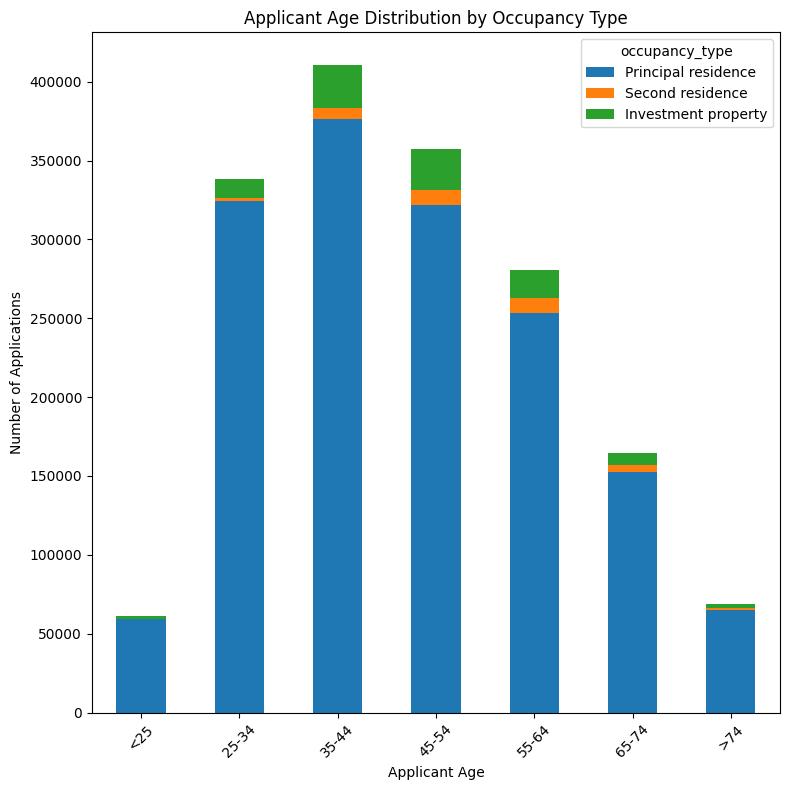

In [23]:
# I will use stacked bar chart to represent proportion of occupancy type inside age categories.
import matplotlib.pyplot as plt

age_order = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]

age_occupancy_counts = pd.crosstab(
    df_visual_copy["applicant_age"],
    df_visual_copy["occupancy_type"]
)

age_occupancy_counts = age_occupancy_counts.reindex(age_order) # this code set index in the suggested order. 

fig, ax = plt.subplots(figsize=(8, 8))

age_occupancy_counts.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title("Applicant Age Distribution by Occupancy Type")
ax.set_xlabel("Applicant Age")
ax.set_ylabel("Number of Applications")

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

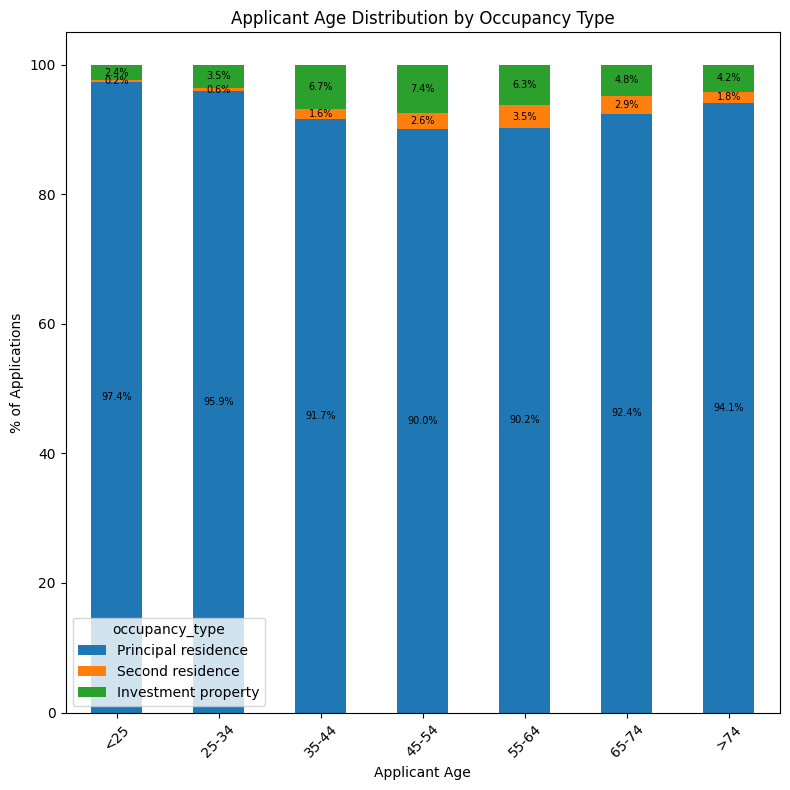

In [33]:
# I will use stacked bar chart to represent proportion of occupancy type inside age categories.
import matplotlib.pyplot as plt

age_order = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]

age_occupancy_pct = round(pd.crosstab(
    df_visual_copy["applicant_age"],
    df_visual_copy["occupancy_type"],
    normalize = "index" 
) * 100, 2)

age_occupancy_pct = age_occupancy_pct.reindex(age_order) # this code set index in the suggested order. 

fig, ax = plt.subplots(figsize=(8, 8))

age_occupancy_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

# Add percentage labels inside each stacked segment
for container in ax.containers: # Each container represents one stacked part of the bar
    ax.bar_label(
        container,
        fmt="%.1f%%",  # %% = escaped percent sign
        label_type="center",
        fontsize=7
    )

ax.set_title("Applicant Age Distribution by Occupancy Type")
ax.set_xlabel("Applicant Age")
ax.set_ylabel("% of Applications")

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

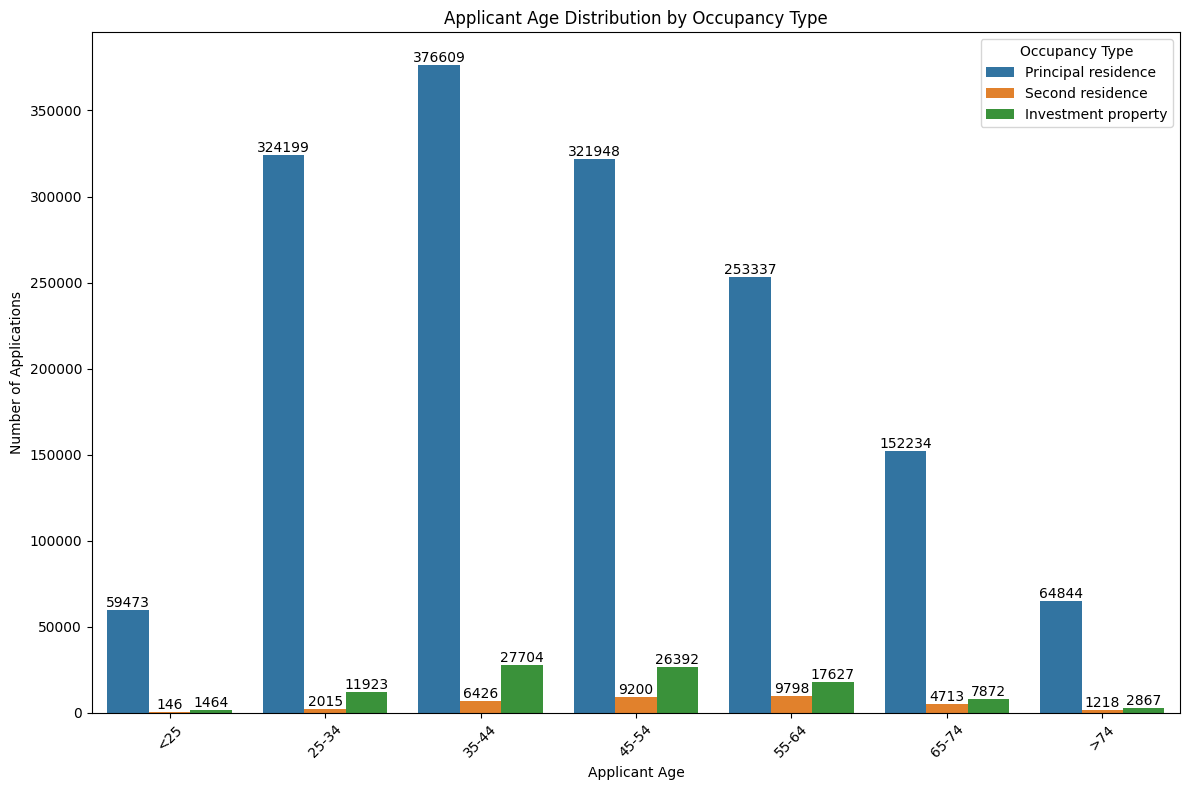

In [24]:
# And using seaborn to present the same data using grouped column chart. 
import seaborn as sns

age_order = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]

fig, ax = plt.subplots(figsize=(12, 8))

sns.countplot(
    data=df_visual_copy,
    x="applicant_age",
    hue="occupancy_type",
    order=age_order,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

ax.set_title("Applicant Age Distribution by Occupancy Type")
ax.set_xlabel("Applicant Age")
ax.set_ylabel("Number of Applications")

ax.tick_params(axis="x", rotation=45)
ax.legend(title="Occupancy Type")

plt.tight_layout()
plt.show()

We can observe from the presented graphs that the principal residence purpose is the main class in all age categories. In addition, most applications were grouped in the 35-44 age bin. This suggests that most mortgage applications are connected with the home ownership rather than investments.